## Load Feature from Metadata into Athena

In [2]:
import json
import awswrangler as wr
from pyathena import connect

# Load saved table name
with open("featurestore_metadata.json", "r") as f:
    metadata = json.load(f)

athena_table_name = metadata["athena_table_name"]
athena_db = "sagemaker_featurestore"

query = f'SELECT * FROM "{athena_db}"."{athena_table_name}"'
print(f"Running query: {query}")

athena_df = wr.athena.read_sql_query(query, database=athena_db, ctas_approach=False)
data = athena_df.copy()


Running query: SELECT * FROM "sagemaker_featurestore"."diabetes_feature_group_1750382712_1750382712"


2025-06-20 01:33:26,066	INFO worker.py:1821 -- Started a local Ray instance.


In [23]:
# FOR FASTER CODE DEVELOPMENT, UNCOMMENT THIS

# import pandas as pd

# data = pd.read_pickle("data/cleaned_data.pkl")
# print(f"Loaded data from local pickle file: {data.shape}")


Loaded data from local pickle file: (101766, 53)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 56 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   recordid                  0 non-null      Int64  
 1   encounter_id              0 non-null      Int64  
 2   patient_nbr               0 non-null      Int64  
 3   race                      0 non-null      string 
 4   gender                    0 non-null      string 
 5   age                       0 non-null      string 
 6   weight                    0 non-null      string 
 7   admission_type_id         0 non-null      Int64  
 8   discharge_disposition_id  0 non-null      Int64  
 9   admission_source_id       0 non-null      Int64  
 10  time_in_hospital          0 non-null      Int64  
 11  payer_code                0 non-null      string 
 12  medical_specialty         0 non-null      string 
 13  num_lab_procedures        0 non-null      Int64  
 14  num_procedures        

## Feature Engineering

In [16]:
## Fix NaNs

# Use lowercase 'a1cresult' due to Athena conversion
glu_order = ["None", "Norm", ">200", ">300"]
a1c_order = ["None", "Norm", ">7", ">8"]

glu_order_with_missing = ["missing"] + glu_order
a1c_order_with_missing = ["missing"] + a1c_order

data['max_glu_serum'] = (
    pd.Categorical(data['max_glu_serum'].fillna("missing"),
                   categories=glu_order_with_missing,
                   ordered=True)
    .astype(str)
)

data['a1cresult'] = (
    pd.Categorical(data['a1cresult'].fillna("missing"),
                   categories=a1c_order_with_missing,
                   ordered=True)
    .astype(str)
)


  readmitted  readmitted_flag
0        >30                0
1        >30                0
2         NO                0
3         NO                0
4        >30                0


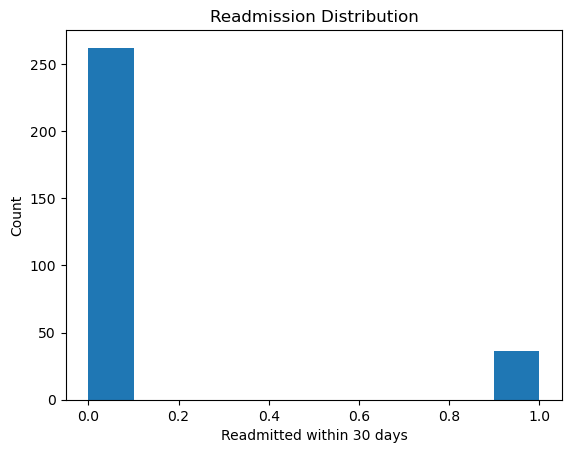

In [18]:
# Readmitted flag for binary classification

import matplotlib.pyplot as plt

data['readmitted_flag'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
print(data[['readmitted', 'readmitted_flag']].head())

plt.hist(data['readmitted_flag'])
plt.title("Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Count")
plt.show()

In [19]:
# delete unnecessary columns

drop_cols = [
    'encounter_id', 'patient_nbr', 'readmitted', 'recordid', 'eventtime',
    'write_time', 'api_invocation_time', 'is_deleted', 'diag_1', 'diag_2', 'diag_3'
]
data = data.drop(columns=drop_cols, errors='ignore')

In [20]:
# X and y

X = data.drop(columns=['readmitted_flag'])
y = data['readmitted_flag']

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())


X shape: (298, 45)
y value counts:
 readmitted_flag
0    262
1     36
Name: count, dtype: int64
